In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/Food_Delivery_Times (1).csv")

In [4]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
df.shape

(1000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [7]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [8]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [9]:
data = df.copy()

In [10]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64','float64'])

In [21]:
data = data.drop('Order_ID', axis=1)

In [22]:

for cols in cat_cols:
  data[cols] = data[cols].fillna(data[cols].mode()[0])


In [23]:
data["Courier_Experience_yrs"] = data["Courier_Experience_yrs"].fillna(data["Courier_Experience_yrs"].mode()[0])

In [24]:
data.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


### Visualizing Delivery_Time_min

Let's visualize the distribution of `Delivery_Time_min` using a histogram and a box plot to understand its central tendency, spread, and identify any potential outliers.

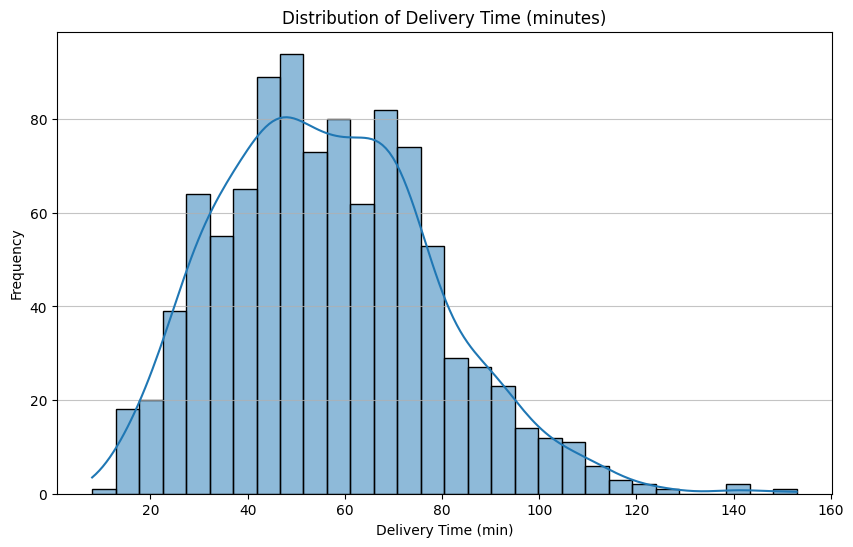

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

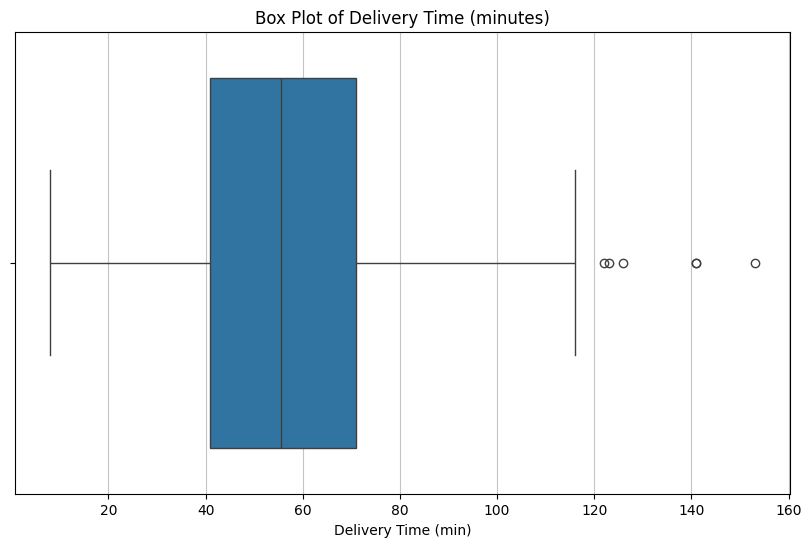

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.grid(axis='x', alpha=0.75)
plt.show()

<Axes: xlabel='Distance_km', ylabel='Delivery_Time_min'>

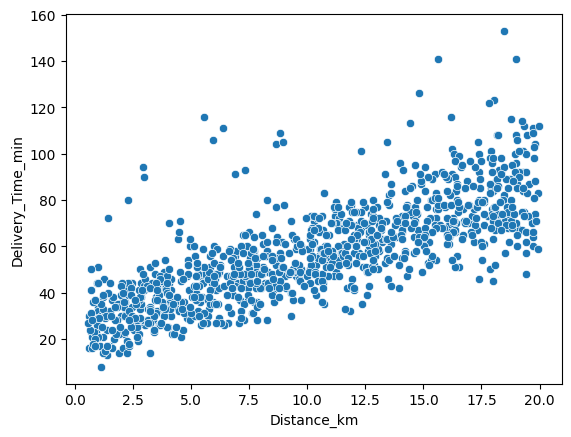

In [27]:
sns.scatterplot(data= df,x= "Distance_km",y = "Delivery_Time_min")

### Relationship between Delivery Time and Categorical Features

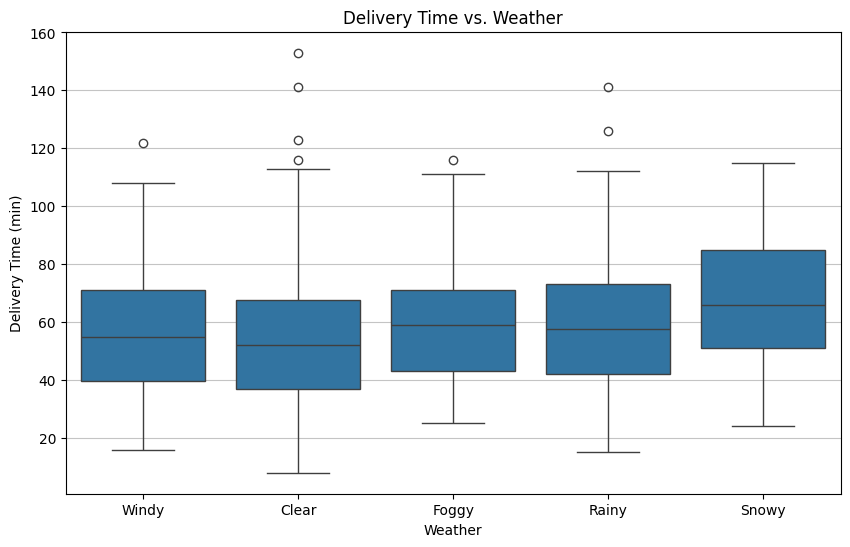

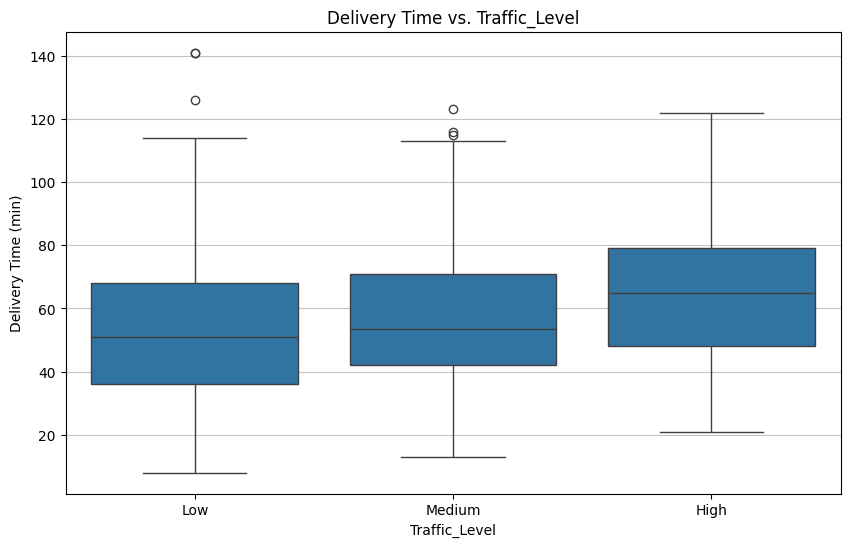

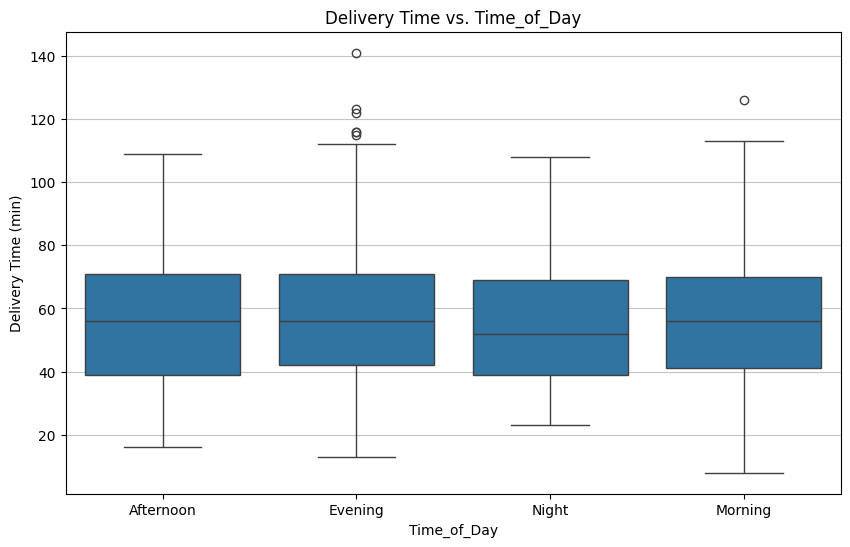

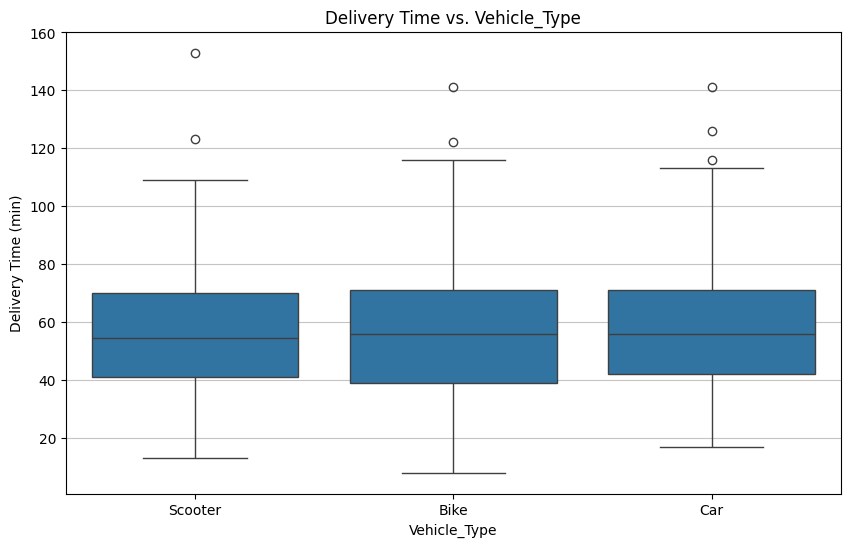

In [28]:


for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:

    data[col] = le.fit_transform(
        data[col]
    )

In [30]:
data.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


In [31]:
from sklearn.model_selection import train_test_split

In [33]:
X = data.drop(["Delivery_Time_min"],axis= 1)
y = data["Delivery_Time_min"]

In [34]:
X.head(5)

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [37]:
from sklearn.metrics import r2_score

In [38]:
r2_score(y_test,model.predict(X_test))

0.7561358993569947

In [42]:
y_pred = model.predict(X_test)

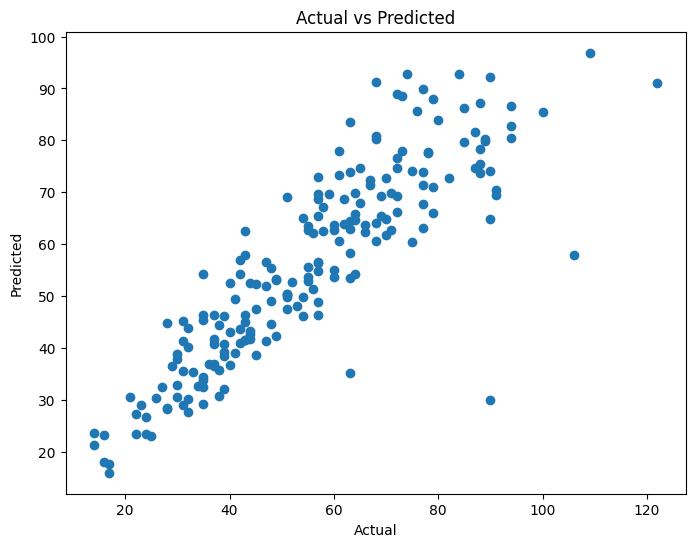

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [44]:
import joblib
joblib.dump(model, 'House_pred.pkl')

['House_pred.pkl']